<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_3/Assignment/Week_3_Sentiment_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOC 2026 — Week 3 Assignment
## Sentiment Analysis using RNN

This notebook implements a recurrent neural network (RNN) to perform sentiment analysis on tweets. We use the `selected_text` column from the Kaggle dataset (`abhi8923shriv/sentiment-analysis-dataset`) and tokenize the input using Hugging Face's `AutoTokenizer` (pre-trained BERT tokenizer).

### 1. Imports and Verification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import kagglehub
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 2. Load Dataset using kagglehub

In [2]:
print("Downloading dataset...")
dataset_dir = kagglehub.dataset_download('abhi8923shriv/sentiment-analysis-dataset')
train_path = os.path.join(dataset_dir, 'train.csv')

# Load and clean
df = pd.read_csv(train_path, encoding='latin1')
df = df.dropna(subset=['selected_text', 'sentiment'])

# Map sentiment labels to integers (0: neutral, 1: positive, 2: negative)
sentiment_map = {'neutral': 0, 'positive': 1, 'negative': 2}
df['label'] = df['sentiment'].map(sentiment_map)

print(f"Loaded dataset with {len(df)} samples.")
print(df['sentiment'].value_counts())
df.head()

Loaded dataset with 27480 samples.
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),label
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105,2
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18,2
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,2
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26,2


### 3. Preprocessing and Tokenization with Hugging Face

In [3]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

texts = df['selected_text'].tolist()
labels = df['label'].tolist()

# Tokenize texts
encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

input_ids = encodings['input_ids'].numpy()
labels = np.array(labels, dtype=np.int64)

# Split into 80/20 train/validation sets
np.random.seed(42)
indices = np.random.permutation(len(input_ids))
split = int(0.8 * len(input_ids))
train_idx, val_idx = indices[:split], indices[split:]

X_train, y_train = input_ids[train_idx], labels[train_idx]
X_val, y_val = input_ids[val_idx], labels[val_idx]

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

Loading tokenizer...


Training set: 21984 samples
Validation set: 5496 samples


### 4. PyTorch Dataset and DataLoaders

In [4]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SentimentDataset(X_train, y_train)
val_dataset = SentimentDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

Train batches: 172, Validation batches: 43


### 5. RNN Model with Embedding and Max Pooling

In [5]:
class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, pad_idx):
        super().__init__()
        # Embedding layer (we explicitly ignore padding index embeddings)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # RNN Layer
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        # Fully connected projection layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        rnn_out, _ = self.rnn(embedded)  # (batch_size, seq_len, hidden_size)
        
        # Max pooling over the sequence dimension (dim=1) to capture most salient features
        pooled, _ = torch.max(rnn_out, dim=1)  # (batch_size, hidden_size)
        
        logits = self.fc(pooled)  # (batch_size, num_classes)
        return logits

# Model parameters
VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM = 64
HIDDEN_SIZE = 128
NUM_CLASSES = 3
PAD_IDX = tokenizer.pad_token_id

model = RNNSentiment(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX
).to(device)

print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

RNNSentiment(
  (embedding): Embedding(30522, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)
Total trainable parameters: 1,978,627


### 6. Training Loop

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Starting training loop...")
for epoch in range(epochs):
    # Training Mode
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
        
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    
    # Validation Mode
    model.eval()
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            total_val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Starting training loop...
Epoch 01/05 | Train Loss: 0.7321 | Train Acc: 68.87% | Val Loss: 0.6181 | Val Acc: 75.76%
Epoch 02/05 | Train Loss: 0.5538 | Train Acc: 78.17% | Val Loss: 0.5238 | Val Acc: 79.71%
Epoch 03/05 | Train Loss: 0.4695 | Train Acc: 82.18% | Val Loss: 0.5024 | Val Acc: 80.51%
Epoch 04/05 | Train Loss: 0.4098 | Train Acc: 84.60% | Val Loss: 0.4623 | Val Acc: 82.55%
Epoch 05/05 | Train Loss: 0.3647 | Train Acc: 86.60% | Val Loss: 0.4637 | Val Acc: 82.57%


### 7. Plot Loss and Accuracy Curves

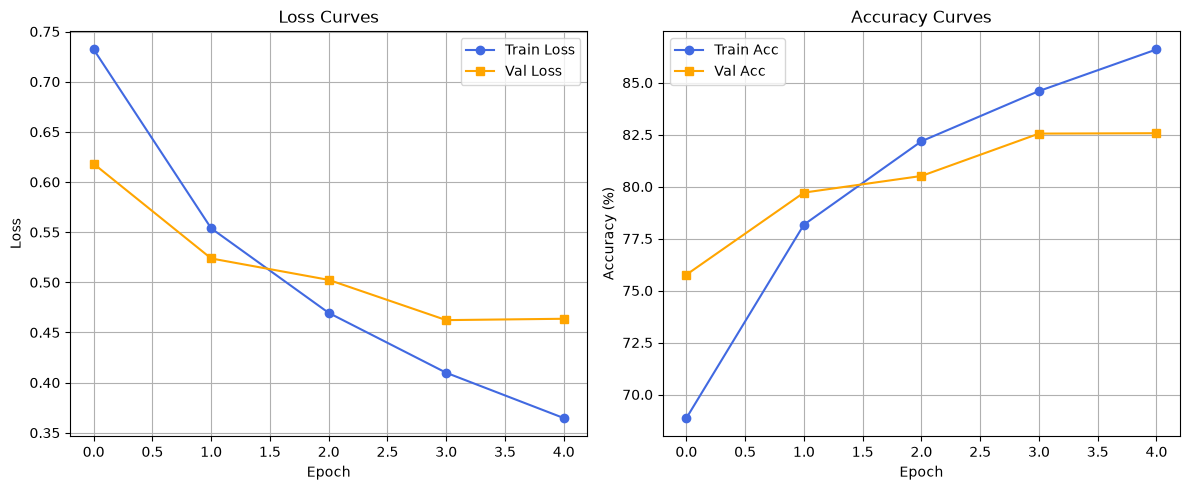

In [7]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='royalblue', marker='o')
plt.plot(val_losses, label='Val Loss', color='orange', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot([acc * 100 for acc in train_accs], label='Train Acc', color='royalblue', marker='o')
plt.plot([acc * 100 for acc in val_accs], label='Val Acc', color='orange', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 8. Verify Model on Custom Sentences

In [8]:
def predict_sentiment(text):
    model.eval()
    with torch.no_grad():
        # Tokenize and encode input
        inputs = tokenizer(text, padding=True, truncation=True, max_length=64, return_tensors="pt")
        input_ids = inputs['input_ids'].to(device)
        
        # Predict logits
        logits = model(input_ids)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_class = np.argmax(probs)
        
        classes = ['neutral', 'positive', 'negative']
        print(f"Text: \"{text}\"")
        print(f"Prediction: {classes[pred_class]} | Probability: {probs[pred_class]*100:.2f}%")
        print(f"All probabilities: Neutral: {probs[0]*100:.2f}%, Positive: {probs[1]*100:.2f}%, Negative: {probs[2]*100:.2f}%\n")

# Test custom inputs
predict_sentiment("I am so happy and excited about this new project!")
predict_sentiment("This is a bad day, nothing went right.")
predict_sentiment("I went to the store and bought some groceries today.")

Text: "I am so happy and excited about this new project!"
Prediction: positive | Probability: 95.97%
All probabilities: Neutral: 3.43%, Positive: 95.97%, Negative: 0.60%

Text: "This is a bad day, nothing went right."
Prediction: negative | Probability: 90.13%
All probabilities: Neutral: 8.02%, Positive: 1.85%, Negative: 90.13%

Text: "I went to the store and bought some groceries today."
Prediction: neutral | Probability: 71.58%
All probabilities: Neutral: 71.58%, Positive: 25.09%, Negative: 3.33%

